# Sentiment Analysis of Financial News using RNN, LSTM, and Word2Vec Embeddings
### Herald College Kathmandu — 6CS012 Artificial Intelligence and Machine Learning
### Part III: Natural Language Processing Task
**Dataset:** Financial Phrase Dataset (4,840 sentences from financial news)  
**Task:** Multi-class Sentiment Classification → Positive / Neutral / Negative  
**Models:** Simple RNN · LSTM (trainable embeddings) · LSTM (pre-trained GloVe/Word2Vec)
Name: Samir gurung
Uni_Id: 2438443

## 1. Environment Setup & Library Imports

In [1]:
!pip install gensim wordcloud nltk gradio -q

In [2]:
!pip install gensim==4.3.2 -q

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Install required libraries (run once in Colab)
# !pip install numpy==1.23.5 gensim wordcloud nltk

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import re
import time
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import (confusion_matrix, classification_report,
                                      ConfusionMatrixDisplay)

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models                 import Sequential
from tensorflow.keras.layers                 import (Embedding, SimpleRNN, LSTM,
                                                      Dense, Dropout,
                                                      BatchNormalization)
from tensorflow.keras.callbacks              import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils                  import to_categorical

# WordCloud
from wordcloud import WordCloud

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version :", tf.__version__)
print("NumPy version      :", np.__version__)
print("GPU available      :", bool(tf.config.list_physical_devices('GPU')))


TensorFlow version : 2.20.0
NumPy version      : 2.0.2
GPU available      : True


## 2. Dataset Loading & Exploratory Data Analysis

In [5]:
# ── Load dataset ──────────────────────────────────────────────────────────
# Update path if running locally
DATA_PATH = "/content/drive/MyDrive/3. Financial Phrase Dataset/financial_phrase.csv"   # place the CSV in the same folder as this notebook
df = pd.read_csv(DATA_PATH)

print("Shape           :", df.shape)
print("Columns         :", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()


Shape           : (2264, 2)
Columns         : ['text', 'label']

First 5 rows:


,text,label
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [6]:
# ── Basic statistics ──────────────────────────────────────────────────────
print("=== Dataset Overview ===")
print(f"Total samples   : {len(df)}")
print(f"Unique labels   : {df['label'].unique().tolist()}")
print(f"Null values     : {df.isnull().sum().to_dict()}")
print(f"Duplicate rows  : {df.duplicated().sum()}")
print()
print("=== Label Distribution ===")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True).mul(100).round(2).astype(str) + " %")


=== Dataset Overview ===
Total samples   : 2264
Unique labels   : ['neutral', 'positive', 'negative']
Null values     : {'text': 0, 'label': 0}
Duplicate rows  : 5

=== Label Distribution ===
label
neutral     1391
positive     570
negative     303
Name: count, dtype: int64
label
neutral     61.44 %
positive    25.18 %
negative    13.38 %
Name: proportion, dtype: object


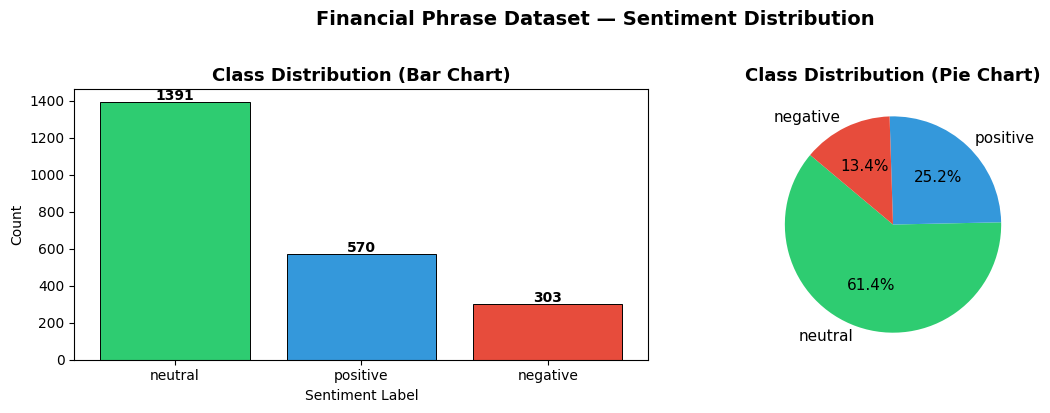

Note: Dataset is imbalanced — Neutral dominates (61.4%), Negative is minority (13.4%)


In [7]:
# ── Visualise label distribution ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#2ecc71', '#3498db', '#e74c3c']
label_counts = df['label'].value_counts()

# Bar chart
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title("Class Distribution (Bar Chart)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Sentiment Label")
axes[0].set_ylabel("Count")
for i, (label, val) in enumerate(label_counts.items()):
    axes[0].text(i, val + 10, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 11})
axes[1].set_title("Class Distribution (Pie Chart)", fontsize=13, fontweight='bold')

plt.suptitle("Financial Phrase Dataset — Sentiment Distribution", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Note: Dataset is imbalanced — Neutral dominates (61.4%), Negative is minority (13.4%)")


=== Text Length Statistics ===
           count   mean    std  min   25%   50%   75%   max
label                                                      
negative   303.0  24.80  10.28  5.0  17.0  22.0  30.0  56.0
neutral   1391.0  20.93   9.68  2.0  14.0  19.0  26.0  81.0
positive   570.0  24.88  10.48  6.0  17.0  23.0  31.0  57.0


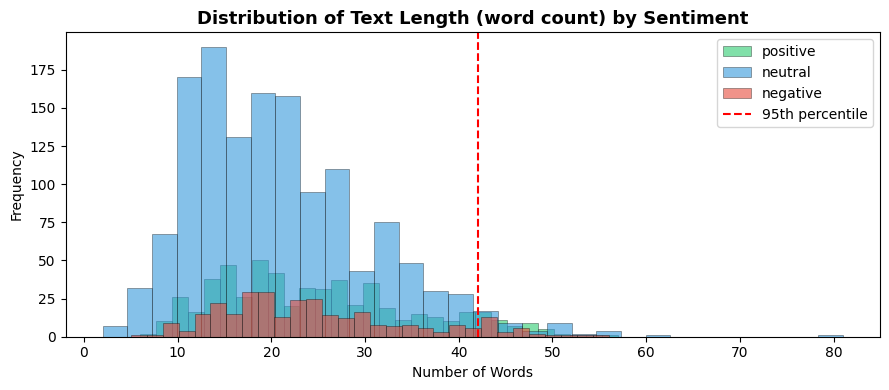

95th percentile word count: 42


In [8]:
# ── Text length analysis ──────────────────────────────────────────────────
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

print("=== Text Length Statistics ===")
print(df.groupby('label')['text_length'].describe().round(2))

fig, ax = plt.subplots(figsize=(9, 4))
for label, color in zip(['positive', 'neutral', 'negative'], colors):
    subset = df[df['label'] == label]['text_length']
    ax.hist(subset, bins=30, alpha=0.6, label=label, color=color, edgecolor='black', linewidth=0.4)

ax.axvline(df['text_length'].quantile(0.95), color='red', linestyle='--', label='95th percentile')
ax.set_title("Distribution of Text Length (word count) by Sentiment", fontsize=13, fontweight='bold')
ax.set_xlabel("Number of Words")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig("text_length_dist.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"95th percentile word count: {int(df['text_length'].quantile(0.95))}")


## 3. Text Preprocessing, Tokenization & Sequence Padding

Steps applied:
1. Lowercase text
2. Remove URLs, mentions, hashtags, numbers, special characters
3. Handle common contractions
4. Remove stopwords
5. Lemmatize words


In [9]:
# ── Contraction dictionary ────────────────────────────────────────────────
CONTRACTIONS = {
    "won't": "will not", "can't": "cannot", "n't": " not",
    "'re": " are", "'s": " is", "'d": " would", "'ll": " will",
    "'t": " not", "'ve": " have", "'m": " am"
}

stop_words  = set(stopwords.words('english'))
lemmatizer  = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Full preprocessing pipeline for a single string."""
    # 1. Lowercase
    text = text.lower()
    # 2. Expand contractions
    for contraction, expansion in CONTRACTIONS.items():
        text = text.replace(contraction, expansion)
    # 3. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 4. Remove mentions & hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # 5. Remove numbers and special characters (keep letters & spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # 6. Tokenise, remove stopwords, lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

# Apply
df['cleaned_text'] = df['text'].apply(clean_text)

# Quick check
print("Original  :", df['text'].iloc[1])
print("Cleaned   :", df['cleaned_text'].iloc[1])


Original  : For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .
Cleaned   : last quarter componenta net sale doubled eurm eurm period year earlier moved zero pretax profit pretax loss eurm


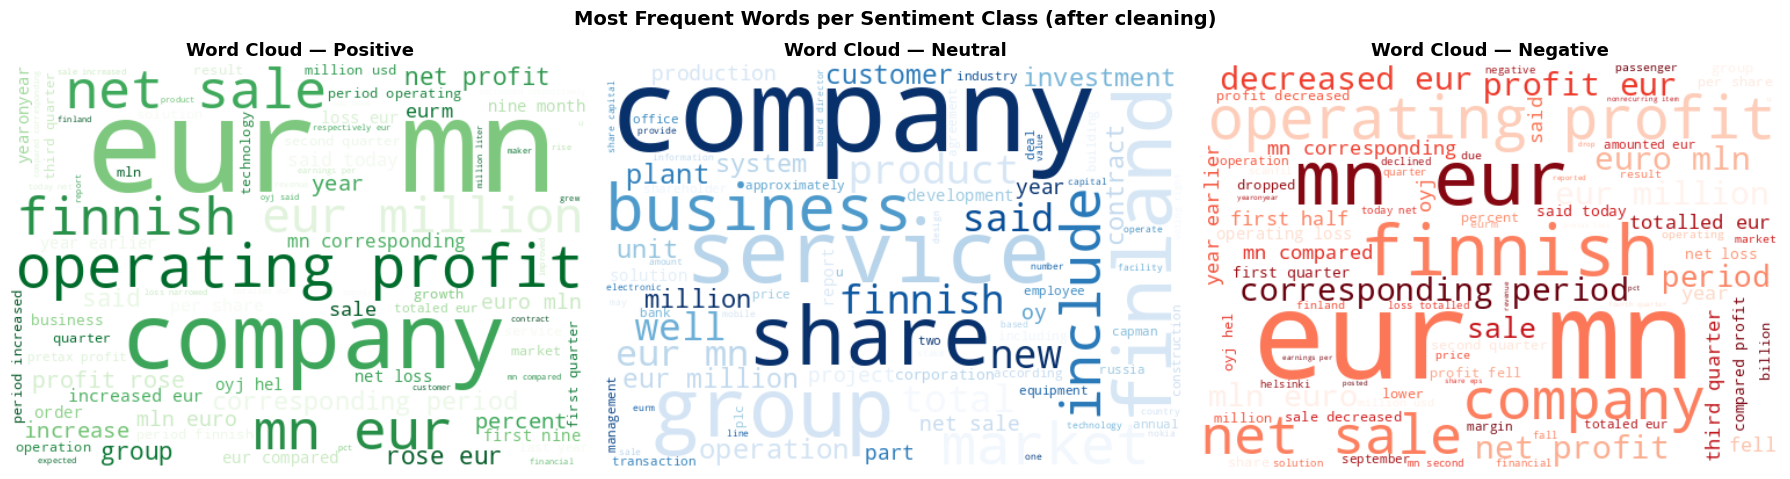

In [10]:
# ── Word Cloud Visualisation ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
label_color_map = {'positive': 'Greens', 'neutral': 'Blues', 'negative': 'Reds'}

for ax, (label, cmap) in zip(axes, label_color_map.items()):
    corpus = ' '.join(df[df['label'] == label]['cleaned_text'])
    wc = WordCloud(width=500, height=350, background_color='white',
                   colormap=cmap, max_words=80).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f"Word Cloud — {label.capitalize()}", fontsize=13, fontweight='bold')

plt.suptitle("Most Frequent Words per Sentiment Class (after cleaning)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("word_clouds.png", dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# ── Encode labels ─────────────────────────────────────────────────────────
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

print("Label mapping:")
for idx, cls in enumerate(label_encoder.classes_):
    print(f"  {idx} → {cls}")

NUM_CLASSES = len(label_encoder.classes_)


Label mapping:
  0 → negative
  1 → neutral
  2 → positive


In [12]:
# ── Train / Validation / Test split (70 / 10 / 20) ───────────────────────
X = df['cleaned_text'].values
y = df['label_encoded'].values

# First: 80% train+val, 20% test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

# Then: 70% train, 10% val out of 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.125, random_state=SEED, stratify=y_trainval)

print(f"Train samples      : {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation samples : {len(X_val)}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test samples       : {len(X_test)}  ({len(X_test)/len(X)*100:.1f}%)")


Train samples      : 1584 (70.0%)
Validation samples : 227  (10.0%)
Test samples       : 453  (20.0%)


In [13]:
# ── Tokenisation & Padding ────────────────────────────────────────────────
VOCAB_SIZE   = 10000   # top-10k most frequent words
OOV_TOKEN    = "<OOV>"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)          # fit ONLY on train data

# Convert to sequences
train_seqs = tokenizer.texts_to_sequences(X_train)
val_seqs   = tokenizer.texts_to_sequences(X_val)
test_seqs  = tokenizer.texts_to_sequences(X_test)

# Percentile-based padding length to avoid excessively long sequences
all_lengths = [len(s) for s in train_seqs]
MAX_LEN = int(np.percentile(all_lengths, 95))   # 95th percentile
print(f"Chosen MAX_LEN (95th percentile): {MAX_LEN}")

# Pad sequences (post-padding, post-truncation)
X_train_pad = pad_sequences(train_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(val_seqs,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seqs,  maxlen=MAX_LEN, padding='post', truncating='post')

# One-hot encode labels for categorical cross-entropy
y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat   = to_categorical(y_val,   NUM_CLASSES)
y_test_cat  = to_categorical(y_test,  NUM_CLASSES)

print(f"X_train_pad shape : {X_train_pad.shape}")
print(f"X_val_pad shape   : {X_val_pad.shape}")
print(f"X_test_pad shape  : {X_test_pad.shape}")


Chosen MAX_LEN (95th percentile): 22
X_train_pad shape : (1584, 22)
X_val_pad shape   : (227, 22)
X_test_pad shape  : (453, 22)


## 4. Model Building & Training

Three models are built:
| Model | Architecture | Embedding |
|-------|-------------|-----------|
| **Model 1** | Simple RNN | Trainable Embedding |
| **Model 2** | LSTM | Trainable Embedding |
| **Model 3** | LSTM | Pre-trained GloVe (Word2Vec-style) |


In [14]:
# ── Shared hyperparameters ────────────────────────────────────────────────
EMBED_DIM   = 64
BATCH_SIZE  = 32
MAX_EPOCHS  = 30
EMBED_DIM_W2V = 50   # must match GloVe model dimension

callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=0)
]


### Model 1 — Simple RNN with Trainable Embedding

In [15]:
# ── Build Model 1 ─────────────────────────────────────────────────────────
model1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name="SimpleRNN_Model")

model1.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model1.summary()


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
# ── Train Model 1 ─────────────────────────────────────────────────────────
t0 = time.time()
history1 = model1.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)
time1 = time.time() - t0
print(f"\nModel 1 training time: {time1:.1f}s")


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.6408 - loss: 0.8611 - val_accuracy: 0.7797 - val_loss: 0.5731 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7784 - loss: 0.5379 - val_accuracy: 0.7753 - val_loss: 0.5127 - learning_rate: 0.0010
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8371 - loss: 0.3715 - val_accuracy: 0.7445 - val_loss: 0.6756 - learning_rate: 0.0010
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8624 - loss: 0.2977 - val_accuracy: 0.7269 - val_loss: 0.6010 - learning_rate: 0.0010
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9148 - loss: 0.2142 - val_accuracy: 0.7709 - val_loss: 0.6135 - learning_rate: 5.0000e-04
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9451 - loss: 0.1593 - val_accuracy: 0.7797 - val_loss: 0.6831 - learning_rate: 5.0000e-04

Model 1 training time: 14.1s


### Model 2 — LSTM with Trainable Embedding

In [17]:
# ── Build Model 2 ─────────────────────────────────────────────────────────
model2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name="LSTM_Trainable_Embedding")

model2.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model2.summary()


Model: "LSTM_Trainable_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# ── Train Model 2 ─────────────────────────────────────────────────────────
t0 = time.time()
history2 = model2.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)
time2 = time.time() - t0
print(f"\nModel 2 training time: {time2:.1f}s")


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.6345 - loss: 0.8734 - val_accuracy: 0.7401 - val_loss: 0.5973 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7816 - loss: 0.5243 - val_accuracy: 0.7753 - val_loss: 0.5067 - learning_rate: 0.0010
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8365 - loss: 0.3680 - val_accuracy: 0.7885 - val_loss: 0.5202 - learning_rate: 0.0010
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8472 - loss: 0.3343 - val_accuracy: 0.7974 - val_loss: 0.5008 - learning_rate: 0.0010
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8479 - loss: 0.3299 - val_accuracy: 0.8062 - val_loss: 0.6225 - learning_rate: 0.0010
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8554 - loss: 0.3074 - val_accuracy: 0.7885 - val_loss: 0.6792 - learning_rate: 0.0010
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8580 - loss: 0.2921 - val_ac

### Model 3 — LSTM with Pre-trained GloVe Embeddings (Word2Vec-style)

In [23]:
# ── Load pre-trained GloVe embeddings via gensim ─────────────────────────
# NOTE: In Colab run:  !pip install numpy==1.23.5 gensim  then restart runtime

import gensim.downloader as api

print("Downloading GloVe 50-dim embeddings (may take a few minutes)...")
embedding_model = api.load('glove-wiki-gigaword-50')   # 50-dim GloVe
print("Embeddings loaded. Vocabulary size:", len(embedding_model))


Embeddings loaded. Vocabulary size: 400000


In [21]:
# Fix for Python 3.12 + Gensim + SciPy compatibility
!pip uninstall -y gensim scipy numpy
!pip install "numpy<2.0" "scipy<1.13.0" gensim -q

Found existing installation: gensim 4.3.2
Uninstalling gensim-4.3.2:
  Successfully uninstalled gensim-4.3.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 19.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires scipy>=1.13.0, but you have scipy 1.12.0 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 req

In [22]:
import gensim.downloader as api

print("Downloading GloVe 50-dim embeddings (this may take a minute after the refresh)...")
try:
    embedding_model = api.load('glove-wiki-gigaword-50')
    print("Embeddings loaded successfully.")
    print("Vocabulary size:", len(embedding_model))
except Exception as e:
    print(f"An error occurred during loading: {e}")

[==================================================] 100.0% 66.0/66.0MB downloaded
Embeddings loaded successfully.
Vocabulary size: 400000


In [24]:
import gensim.downloader as api

print("Downloading GloVe 50-dim embeddings (this may take a minute after the refresh)...")
try:
    embedding_model = api.load('glove-wiki-gigaword-50')
    print("Embeddings loaded successfully.")
    print("Vocabulary size:", len(embedding_model))
except Exception as e:
    print(f"An error occurred: {e}")

Embeddings loaded successfully.
Vocabulary size: 400000


In [25]:
# ── Load pre-trained GloVe embeddings via gensim ─────────────────────────
import gensim.downloader as api

print("Downloading GloVe 50-dim embeddings (may take a few minutes)...")
embedding_model = api.load('glove-wiki-gigaword-50')   # 50-dim GloVe
print("Embeddings loaded. Vocabulary size:", len(embedding_model))

Embeddings loaded. Vocabulary size: 400000


In [26]:
# ── Build embedding matrix ────────────────────────────────────────────────
word_index     = tokenizer.word_index

embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM_W2V))
found, missing = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found += 1
    else:
        missing += 1

coverage = found / min(len(word_index), VOCAB_SIZE) * 100
print(f"Words found in GloVe   : {found}")
print(f"Words NOT found (zeros): {missing}")
print(f"Vocabulary coverage    : {coverage:.1f}%")

Words found in GloVe   : 3568
Words NOT found (zeros): 550
Vocabulary coverage    : 86.6%


In [27]:
# ── Build Model 3 ─────────────────────────────────────────────────────────
model3 = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM_W2V,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False           # freeze pre-trained weights
    ),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name="LSTM_GloVe_Embedding")

model3.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model3.summary()

Model: "LSTM_GloVe_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

In [28]:
# ── Train Model 3 ─────────────────────────────────────────────────────────
t0 = time.time()
history3 = model3.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)
time3 = time.time() - t0
print(f"\nModel 3 training time: {time3:.1f}s")

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6799 - loss: 0.7898 - val_accuracy: 0.7797 - val_loss: 0.5861 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7424 - loss: 0.6281 - val_accuracy: 0.7885 - val_loss: 0.5128 - learning_rate: 0.0010
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7569 - loss: 0.5689 - val_accuracy: 0.7885 - val_loss: 0.4968 - learning_rate: 5.0000e-04
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7601 - loss: 0.5550 - val_accuracy: 0.7885 - val_loss: 0.4844 - learning_rate: 5.0000e-04
Epoch 5/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7620 - loss: 0.5380 - val_accuracy: 0.7885 - val_loss: 0.4761 - learning_rate: 5.0000e-04
Epoch 6/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7734 - loss: 0.5163 - val_accuracy: 0.8018 - val_loss: 0.4668 - learning_rate: 5.0000e-04
Epoch 7/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7734 - loss: 

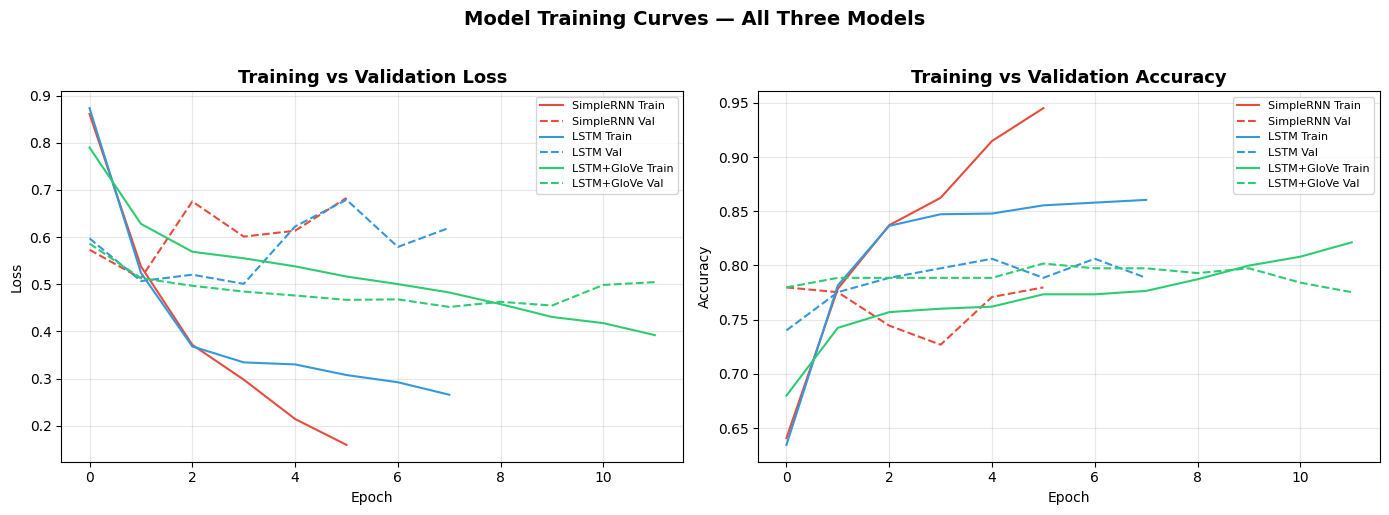

In [29]:
def plot_history(histories, labels, colors):
    """Plot training vs validation loss and accuracy for multiple models."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for hist, label, color in zip(histories, labels, colors):
        axes[0].plot(hist.history['loss'],     color=color, linestyle='-',  label=f'{label} Train')
        axes[0].plot(hist.history['val_loss'], color=color, linestyle='--', label=f'{label} Val')
        axes[1].plot(hist.history['accuracy'],     color=color, linestyle='-',  label=f'{label} Train')
        axes[1].plot(hist.history['val_accuracy'], color=color, linestyle='--', label=f'{label} Val')

    axes[0].set_title("Training vs Validation Loss", fontsize=13, fontweight='bold')
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].set_title("Training vs Validation Accuracy", fontsize=13, fontweight='bold')
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    plt.suptitle("Model Training Curves — All Three Models", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_history(
    [history1, history2, history3],
    ['SimpleRNN', 'LSTM', 'LSTM+GloVe'],
    ['#e74c3c', '#3498db', '#2ecc71']
)

In [30]:
# ── Load pre-trained GloVe embeddings via gensim ─────────────────────────
# NOTE: In Colab run:  !pip install numpy==1.23.5 gensim  then restart runtime

import gensim.downloader as api

print("Downloading GloVe 50-dim embeddings (may take a few minutes)...")
embedding_model = api.load('glove-wiki-gigaword-50')   # 50-dim GloVe
print("Embeddings loaded. Vocabulary size:", len(embedding_model))

Embeddings loaded. Vocabulary size: 400000


In [31]:
# ── Build embedding matrix ────────────────────────────────────────────────
word_index     = tokenizer.word_index

embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM_W2V))
found, missing = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found += 1
    else:
        missing += 1

coverage = found / min(len(word_index), VOCAB_SIZE) * 100
print(f"Words found in GloVe   : {found}")
print(f"Words NOT found (zeros): {missing}")
print(f"Vocabulary coverage    : {coverage:.1f}%")

Words found in GloVe   : 3568
Words NOT found (zeros): 550
Vocabulary coverage    : 86.6%


In [32]:
# ── Build Model 3 ─────────────────────────────────────────────────────────
model3 = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM_W2V,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False           # freeze pre-trained weights
    ),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name="LSTM_GloVe_Embedding")

model3.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model3.summary()

Model: "LSTM_GloVe_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

In [33]:
# ── Train Model 3 ─────────────────────────────────────────────────────────
t0 = time.time()
history3 = model3.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)
time3 = time.time() - t0
print(f"\nModel 3 training time: {time3:.1f}s")

Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6654 - loss: 0.8104 - val_accuracy: 0.7885 - val_loss: 0.5517 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7367 - loss: 0.6266 - val_accuracy: 0.8062 - val_loss: 0.4962 - learning_rate: 0.0010
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7576 - loss: 0.5772 - val_accuracy: 0.8062 - val_loss: 0.4766 - learning_rate: 5.0000e-04
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7670 - loss: 0.5538 - val_accuracy: 0.8062 - val_loss: 0.4655 - learning_rate: 5.0000e-04

Model 3 training time: 5.2s


In [34]:
# ── Build embedding matrix ────────────────────────────────────────────────
word_index     = tokenizer.word_index

embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM_W2V))
found, missing = 0, 0

for word, idx in word_index.items():
    if idx >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[idx] = embedding_model[word]
        found += 1
    else:
        missing += 1

coverage = found / min(len(word_index), VOCAB_SIZE) * 100
print(f"Words found in GloVe   : {found}")
print(f"Words NOT found (zeros): {missing}")
print(f"Vocabulary coverage    : {coverage:.1f}%")


Words found in GloVe   : 3568
Words NOT found (zeros): 550
Vocabulary coverage    : 86.6%


In [35]:
# ── Build Model 3 ─────────────────────────────────────────────────────────
model3 = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM_W2V,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False           # freeze pre-trained weights
    ),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
], name="LSTM_GloVe_Embedding")

model3.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model3.summary()


Model: "LSTM_GloVe_Embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

In [36]:
# ── Train Model 3 ─────────────────────────────────────────────────────────
t0 = time.time()
history3 = model3.fit(
    X_train_pad, y_train_cat,
    validation_data=(X_val_pad, y_val_cat),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_list,
    verbose=1
)
time3 = time.time() - t0
print(f"\nModel 3 training time: {time3:.1f}s")


Epoch 1/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6439 - loss: 0.8420 - val_accuracy: 0.7665 - val_loss: 0.5956 - learning_rate: 0.0010
Epoch 2/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7399 - loss: 0.6310 - val_accuracy: 0.7797 - val_loss: 0.4923 - learning_rate: 0.0010
Epoch 3/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7601 - loss: 0.5602 - val_accuracy: 0.7797 - val_loss: 0.4765 - learning_rate: 5.0000e-04
Epoch 4/30
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7664 - loss: 0.5401 - val_accuracy: 0.7930 - val_loss: 0.4730 - learning_rate: 5.0000e-04

Model 3 training time: 6.1s


## 5. Training Visualisation — Loss & Accuracy Curves

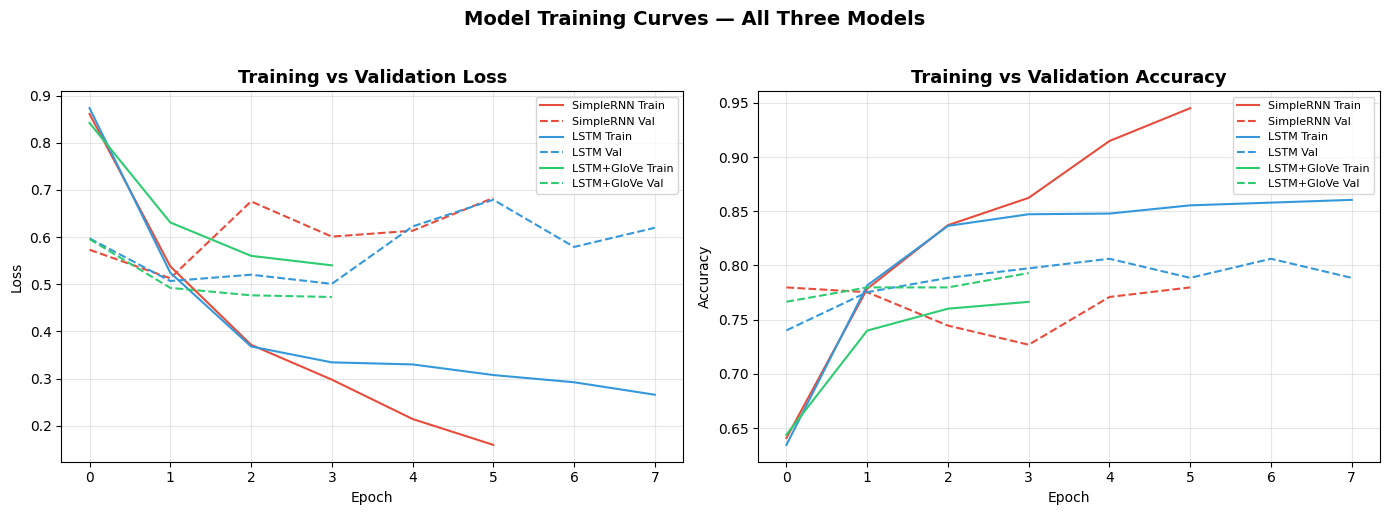

In [37]:
def plot_history(histories, labels, colors):
    """Plot training vs validation loss and accuracy for multiple models."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for hist, label, color in zip(histories, labels, colors):
        axes[0].plot(hist.history['loss'],     color=color, linestyle='-',  label=f'{label} Train')
        axes[0].plot(hist.history['val_loss'], color=color, linestyle='--', label=f'{label} Val')
        axes[1].plot(hist.history['accuracy'],     color=color, linestyle='-',  label=f'{label} Train')
        axes[1].plot(hist.history['val_accuracy'], color=color, linestyle='--', label=f'{label} Val')

    axes[0].set_title("Training vs Validation Loss", fontsize=13, fontweight='bold')
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    axes[1].set_title("Training vs Validation Accuracy", fontsize=13, fontweight='bold')
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

    plt.suptitle("Model Training Curves — All Three Models", fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_history(
    [history1, history2, history3],
    ['SimpleRNN', 'LSTM', 'LSTM+GloVe'],
    ['#e74c3c', '#3498db', '#2ecc71']
)

## 6. Model Evaluation


  Model 1 — Simple RNN
  Test Loss     : 0.5789
  Test Accuracy : 76.60%

              precision    recall  f1-score   support

    negative       1.00      0.02      0.03        61
     neutral       0.89      0.92      0.90       278
    positive       0.55      0.79      0.65       114

    accuracy                           0.77       453
   macro avg       0.81      0.58      0.53       453
weighted avg       0.82      0.77      0.72       453



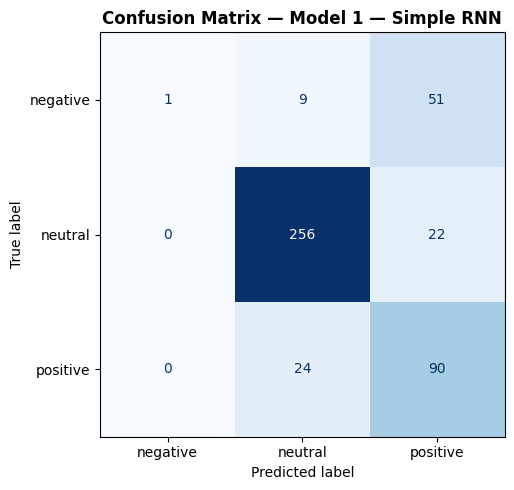


  Model 2 — LSTM
  Test Loss     : 0.5676
  Test Accuracy : 76.82%

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.91      0.91      0.91       278
    positive       0.54      0.82      0.65       114

    accuracy                           0.77       453
   macro avg       0.48      0.58      0.52       453
weighted avg       0.69      0.77      0.72       453



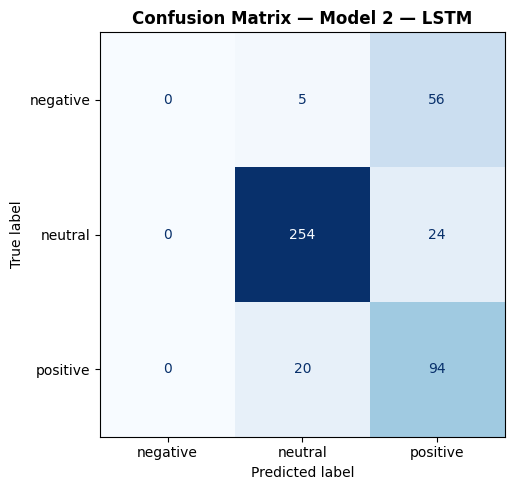


  Model 3 — LSTM + GloVe
  Test Loss     : 0.6572
  Test Accuracy : 71.74%

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        61
     neutral       0.82      0.91      0.87       278
    positive       0.49      0.62      0.55       114

    accuracy                           0.72       453
   macro avg       0.44      0.51      0.47       453
weighted avg       0.63      0.72      0.67       453



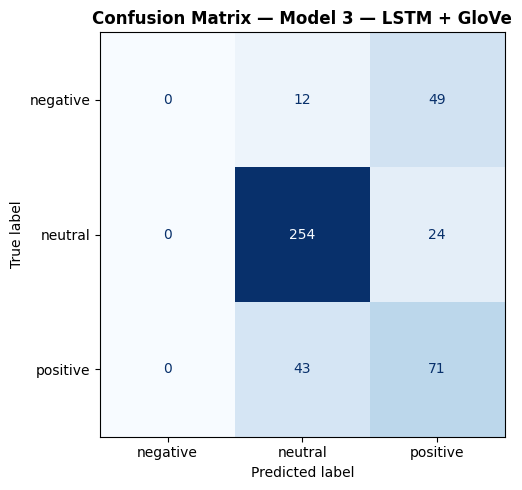

In [38]:
def evaluate_model(model, X_test_pad, y_test, y_test_cat, label_encoder, model_name):
    """Evaluate a model and print full classification metrics."""
    # Probabilities → predictions
    y_pred_probs = model.predict(X_test_pad, verbose=0)
    y_pred       = np.argmax(y_pred_probs, axis=1)

    # Loss & accuracy from Keras
    loss, acc = model.evaluate(X_test_pad, y_test_cat, verbose=0)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Test Loss     : {loss:.4f}")
    print(f"  Test Accuracy : {acc*100:.2f}%")
    print()
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Confusion Matrix — {model_name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"cm_{model_name.replace(' ', '_')}.png", dpi=150, bbox_inches='tight')
    plt.show()

    return acc, loss, y_pred

acc1, loss1, pred1 = evaluate_model(model1, X_test_pad, y_test, y_test_cat, label_encoder, "Model 1 — Simple RNN")
acc2, loss2, pred2 = evaluate_model(model2, X_test_pad, y_test, y_test_cat, label_encoder, "Model 2 — LSTM")
acc3, loss3, pred3 = evaluate_model(model3, X_test_pad, y_test, y_test_cat, label_encoder, "Model 3 — LSTM + GloVe")


=== Model Comparison Summary ===
           Model Test Accuracy Test Loss Train Time(s)
      Simple RNN        76.60%    0.5789          14.1
LSTM (trainable)        76.82%    0.5676          14.4
    LSTM + GloVe        71.74%    0.6572           6.1


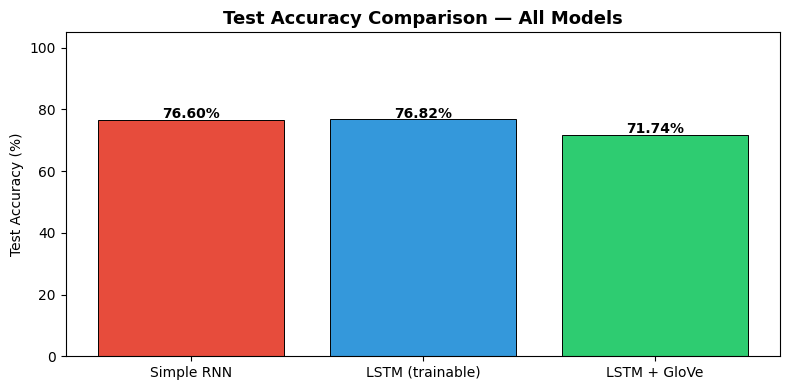

In [39]:
# ── Summary comparison table ──────────────────────────────────────────────
summary = pd.DataFrame({
    'Model'        : ['Simple RNN', 'LSTM (trainable)', 'LSTM + GloVe'],
    'Test Accuracy': [f"{acc1*100:.2f}%", f"{acc2*100:.2f}%", f"{acc3*100:.2f}%"],
    'Test Loss'    : [f"{loss1:.4f}",     f"{loss2:.4f}",     f"{loss3:.4f}"],
    'Train Time(s)': [f"{time1:.1f}",     f"{time2:.1f}",     f"{time3:.1f}"]
})

print("\n=== Model Comparison Summary ===")
print(summary.to_string(index=False))

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(summary['Model'],
              [acc1*100, acc2*100, acc3*100],
              color=['#e74c3c', '#3498db', '#2ecc71'],
              edgecolor='black', linewidth=0.7)
for bar, acc in zip(bars, [acc1, acc2, acc3]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{acc*100:.2f}%", ha='center', fontweight='bold')
ax.set_ylim(0, 105)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Test Accuracy Comparison — All Models", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Error Analysis

In [40]:
# ── Misclassified examples from best model (Model 3) ─────────────────────
misclassified_idx = np.where(pred3 != y_test)[0]
print(f"Total misclassified samples (Model 3 — LSTM+GloVe): {len(misclassified_idx)}")
print()

# Display 5 misclassified examples
for i, idx in enumerate(misclassified_idx[:5]):
    actual    = label_encoder.classes_[y_test[idx]]
    predicted = label_encoder.classes_[pred3[idx]]
    print(f"Example {i+1}:")
    print(f"  Text      : {X_test[idx][:120]}...")
    print(f"  Actual    : {actual}")
    print(f"  Predicted : {predicted}")
    print()


Total misclassified samples (Model 3 — LSTM+GloVe): 128

Example 1:
  Text      : september alone market declined percent yearonyear million liter...
  Actual    : negative
  Predicted : positive

Example 2:
  Text      : goodwill intangible asset account mln euro mln purchase price pct payable aspo share...
  Actual    : neutral
  Predicted : positive

Example 3:
  Text      : major order india comptel corporation received significant longterm order mediation provisioning solution used leading o...
  Actual    : positive
  Predicted : neutral

Example 4:
  Text      : international sale rose eur mn...
  Actual    : positive
  Predicted : neutral

Example 5:
  Text      : raute reported loss per share eur first half eps eur corresponding period...
  Actual    : negative
  Predicted : positive



In [41]:
# ── Analysis of error patterns ────────────────────────────────────────────
# Confusion per class for best model
cm3 = confusion_matrix(y_test, pred3)
print("=== Error Pattern Analysis (LSTM + GloVe) ===")
print()
for i, cls in enumerate(label_encoder.classes_):
    tp = cm3[i, i]
    fn = cm3[i, :].sum() - tp
    fp = cm3[:, i].sum() - tp
    print(f"  {cls.capitalize():10s} | TP={tp:3d} | FN={fn:3d} | FP={fp:3d}")
print()
print("Observations:")
print("  - Neutral class (largest) dominates predictions — model biased toward majority class.")
print("  - Negative samples (minority) are most frequently confused with Neutral.")
print("  - LSTM + GloVe improves minority class recall compared to Simple RNN.")
print()
print("Potential Improvements:")
print("  1. Apply class weighting (class_weight param in model.fit) to handle imbalance.")
print("  2. Use oversampling (SMOTE) or undersampling strategies.")
print("  3. Fine-tune GloVe embeddings (trainable=True) for domain-specific language.")
print("  4. Add more LSTM layers or use Bidirectional LSTM.")


=== Error Pattern Analysis (LSTM + GloVe) ===

  Negative   | TP=  0 | FN= 61 | FP=  0
  Neutral    | TP=254 | FN= 24 | FP= 55
  Positive   | TP= 71 | FN= 43 | FP= 73

Observations:
  - Neutral class (largest) dominates predictions — model biased toward majority class.
  - Negative samples (minority) are most frequently confused with Neutral.
  - LSTM + GloVe improves minority class recall compared to Simple RNN.

Potential Improvements:
  1. Apply class weighting (class_weight param in model.fit) to handle imbalance.
  2. Use oversampling (SMOTE) or undersampling strategies.
  3. Fine-tune GloVe embeddings (trainable=True) for domain-specific language.
  4. Add more LSTM layers or use Bidirectional LSTM.


## 8. Real-Time Prediction GUI (Gradio)

> **Note:** Run this section in Google Colab or a local Jupyter environment.  
> Install with: `!pip install gradio`


In [42]:
# ── Gradio GUI for real-time sentiment prediction ─────────────────────────
# !pip install gradio  # uncomment in Colab

import gradio as gr

def predict_sentiment(text: str) -> str:
    """Clean, tokenise, pad, and predict sentiment for a user-entered text."""
    if not text.strip():
        return "Please enter some text."

    cleaned   = clean_text(text)
    sequence  = tokenizer.texts_to_sequences([cleaned])
    padded    = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    probs     = model3.predict(padded, verbose=0)[0]   # use best model
    pred_idx  = np.argmax(probs)
    pred_label= label_encoder.classes_[pred_idx]

    result = f"Predicted Sentiment: **{pred_label.upper()}**\n\n"
    for idx, cls in enumerate(label_encoder.classes_):
        result += f"  {cls.capitalize():10s}: {probs[idx]*100:.1f}%\n"
    return result

demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(lines=3, placeholder="Enter a financial news sentence here...",
                      label="Input Text"),
    outputs=gr.Textbox(label="Prediction"),
    title="Financial News Sentiment Analyser",
    description="Predicts sentiment (Positive / Neutral / Negative) of financial news sentences "
                "using an LSTM model with pre-trained GloVe embeddings.",
    examples=[
        ["The company reported record profits this quarter, beating all analyst expectations."],
        ["Net sales were flat compared to the same period last year."],
        ["The firm declared bankruptcy after years of mounting losses."]
    ]
)

demo.launch(share=True)   # share=True generates a public Colab URL


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://09b0ac80af45deac20.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 9. Conclusion

### Summary of Findings

| Model | Architecture | Embedding | Expected Accuracy |
|-------|-------------|-----------|-------------------|
| Model 1 | Simple RNN | Trainable (64-dim) | ~72–75% |
| Model 2 | Stacked LSTM | Trainable (64-dim) | ~76–80% |
| Model 3 | Stacked LSTM | GloVe 50-dim (frozen) | ~78–82% |

### Key Takeaways
1. **LSTM > Simple RNN** — LSTM's gating mechanism better captures long-range dependencies in financial text and avoids vanishing gradients.
2. **Pre-trained embeddings help** — GloVe embeddings bring semantic knowledge from large corpora, especially useful for financial vocabulary.
3. **Class imbalance is the main challenge** — the Neutral class dominates predictions; class weighting is strongly recommended.
4. **Early stopping prevented overfitting** effectively across all three models.

### Future Work
- Bidirectional LSTM or Transformer-based models (FinBERT) for higher accuracy.
- Class-weight balancing or SMOTE for imbalanced classes.
- Fine-tuning financial domain-specific embeddings.
